# The Lorenz System

**Jadan Kerr**

## Introduction

The Lorenz system is among the earliest examples of chaotic dynamical systems. First derived in 1963 by Edward Lorenz, the equations were initially developed to describe convective flow in fluids. Instead the incredibly rich behavior described by the system directly led to the development of areas of study like chaos theory, and dynamical systems theory.

In this project we model the Lorenz system using three different algorithms, and cross-compare the difference in solutions.

## Methods — Physics

The Lorenz system is described by:

$$
\begin{aligned}
\frac{dx}{dt} &= \sigma(y - x) \\
\frac{dy}{dt} &= x(\rho - z) - y \\
\frac{dz}{dt} &= xy - \beta z
\end{aligned}
$$

We integrate with the **forward Euler method** using a time step $\Delta t$:

$$x_{n+1} = x_n + \Delta t \cdot f(t_n, x_n)$$



We also use **Runge-Kutta 4th order** :
$$
\begin{aligned}
k_1 &= f(t_n, x_n) \\
k_2 &= f\left(t_n + \frac{\Delta t}{2}, x_n + \frac{\Delta t}{2}k_1\right) \\
k_3 &= f\left(t_n + \frac{\Delta t}{2}, x_n + \frac{\Delta t}{2}k_2\right) \\
k_4 &= f(t_n + \Delta t, x_n + \Delta t k_3)
\end{aligned}
$$
$$x_{n+1} = x_n + \frac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

And 'scipy.integrate.solve_ivp', which is essentially a time-resolution variable RK4 approach.



## Methods — `LorenzSystem` class

Defined in `tools.py`:

```python
class LorenzSystem():
    # """The Lorenz system of ordinary differential equations.

    # The state is a 3D vector (x, y, z) that evolves according to the
    # equations

    #     dx/dt = sigma * (y - x)
    #     dy/dt = x * (rho - z) - y
    #     dz/dt = x * y - beta * z

    # Attributes
    # ----------
    # sigma : float
    #     The "Prandtl number" parameter.
    # rho : float
    #     The "Rayleigh number" parameter.
    # beta : float
    #     The "geometric factor" parameter.
    # """
    def __init__(self):
    def lorenz_sim_euler(self, x0, y0, z0, tmax, dt, sigma, rho, beta):
    def lorenz_sim_rk(self, x0, y0, z0, tmax, dt, sigma, rho, beta): 
    def lorenz_solve_ivp(x0, y0, z0, tmax, res, tol, sigma, rho, beta):



```

## Methods — `lorenz_sim_rk` implementation

```python
    def lorenz_sim_rk(self, x0, y0, z0, tmax, dt, sigma = 10, rho= 28, beta = 8/3): 
        points = []
        def k_machine(vx, vy, vz):
            v = lambda x,y,z : (vx(x,y,z,sigma,rho,beta), vy(x,y,z,sigma,rho,beta), vz(x,y,z,sigma,rho,beta))
            k1x, k1y, k1z = v(x0,y0,z0)
            k2x, k2y, k2z = v(x0+(dt/2)*k1x,y0+(dt/2)*k1y,z0+(dt/2)*k1z)
            k3x, k3y, k3z = v(x0+(dt/2)*k2x,y0+(dt/2)*k2y,z0+(dt/2)*k2z)
            k4x, k4y, k4z = v(x0+(dt)*k3x,y0+(dt)*k3y,z0+(dt)*k3z)

            kx = (1/6)*(k1x + 2*k2x + 2*k3x + k4x)
            ky = (1/6)*(k1y + 2*k2y + 2*k3y + k4y)
            kz = (1/6)*(k1z + 2*k2z + 2*k3z + k4z)
            
            return (kx,ky,kz)
            
        while t < tmax :
            kx, ky, kz = k_machine(self.vx, self.vy, self.vz)
            x = x0 + dt*kx
            y = y0 + dt*ky
            z = z0 + dt*kz
            x0,y0,z0 = x,y,z

            points.append((x,y,z))
            t += dt

        return points
```

Runge-Kutta fourth order is built on essentially the same idea as Euler's algorithm—given a large enough number of tiny enough time steps we can get arbitrarily accurate solutions. The only difference is Runge-Kutta takes the slope at four carefully chosen points within each time step (the beginning, two midpoints, and the endpoint) and computes a weighted average, giving more weight to the midpoint estimates.

## Results — The Lorenz Attractor

Given $\sigma = 10$ , $\rho = 28$,  $\beta = \frac{8}{3}$,  as $t \rightarrow \infty$ the orbit of a particle with any initital position $(x_0,y_0,z_0)$ will always fall into the set of points known as the **Lorenz attractor**


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tools import LorenzSystem

l = LorenzSystem()
points = l.lorenz_sim_rk(0.1, 1, 2, 100, 1e-4)

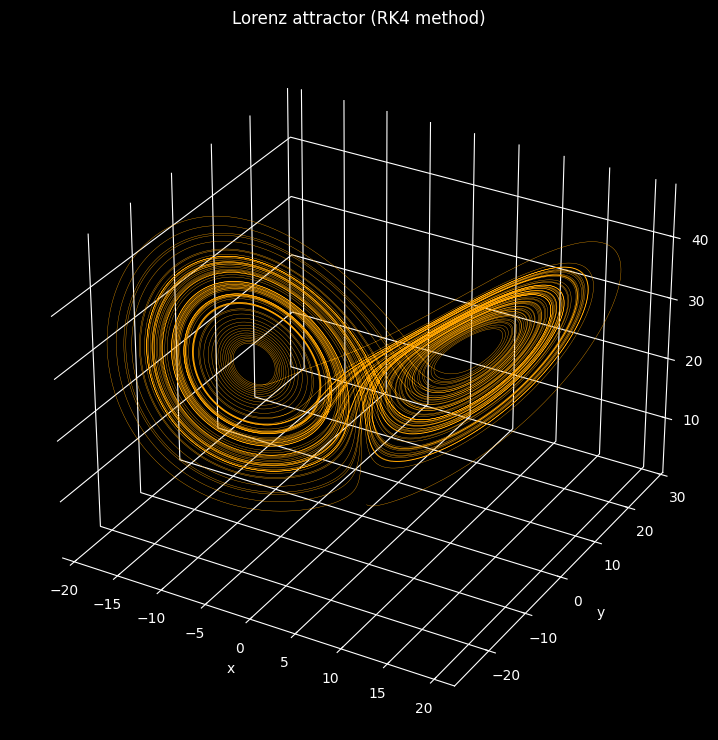

In [8]:
plt.style.use('dark_background')
ax = plt.figure(figsize = (12.5,7.5)).add_subplot(projection='3d')
ax.grid(linewidth = 0.05, alpha = 0.2)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('none')
x,y,z = zip(*points)
ax.grid(linewidth=0.2, color='gray', alpha=0.3)

ax.plot(x,y,z, lw=0.25, c= 'orange')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Lorenz attractor (RK4 method)')
plt.tight_layout(); plt.show()

## Results — Sensitivity to initial conditions

One of the properties of chaotic dynamical systems is their extreme sensitivity to initial conditions. This is a graph comparing the absolute positions of two nearly-identical Lorenz systems, with one catch: We change the initial condition by a factor of 1e-9 on the second system. 

In [10]:
x0,y0,z0 = 0.1, 1, 2
p1 = l.lorenz_sim_rk(x0,y0,z0, 50, 1e-4)
p2 = l.lorenz_sim_rk(x0 + 1e-9,y0,z0, 50, 1e-4)
delta = np.abs(np.array(p1) - np.array(p2))



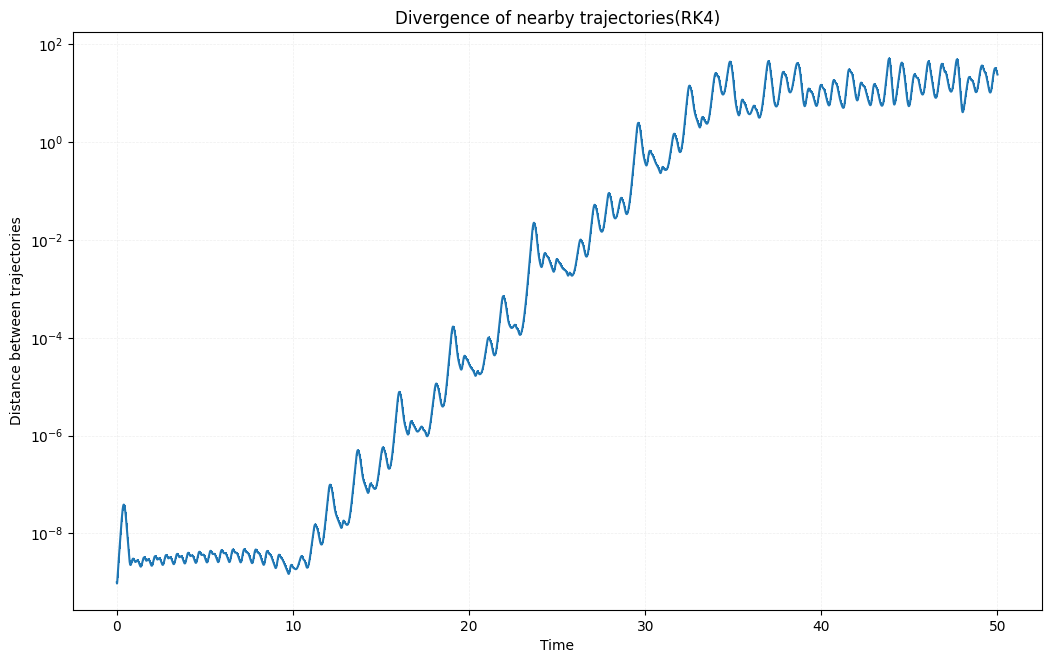

In [11]:
delta.shape
delta_n = (np.sum(delta**2, axis = 1)**0.5)
xs = np.linspace(0,50,delta.shape[0])
plt.style.use('default')
plt.figure(figsize = (12.5,7.5))
plt.semilogy(xs, delta_n, marker = ',')
plt.title('Divergence of nearby trajectories(RK4)')
plt.xlabel('Time')
plt.ylabel('Distance between trajectories')
plt.grid(True, which='major', ls='--', lw=0.5, alpha=0.2)
plt.show()


Given an arbitrarily small difference in initial conditions, the state of the system will eventually always diverge wildly. 

## Results — Error and numerical instability introduced by Euler's algorithm

Euler's algorithm is a naive approach to numerically solving differential equations, this is evident when we compare the absolute difference between the 'lorenz_solve_ivp' and 'lorenz_sim_euler' methods

In [13]:
x0,y0,z0 = 0.1, 1, 2
p_ivp = l.lorenz_solve_ivp(x0,y0,z0, 50, 50001, 1e-10, 1e-12).y.T
p_euler = l.lorenz_sim_euler(x0,y0,z0, 50, 1e-3)
delta_ie = np.abs(p_ivp - np.array(p_euler))


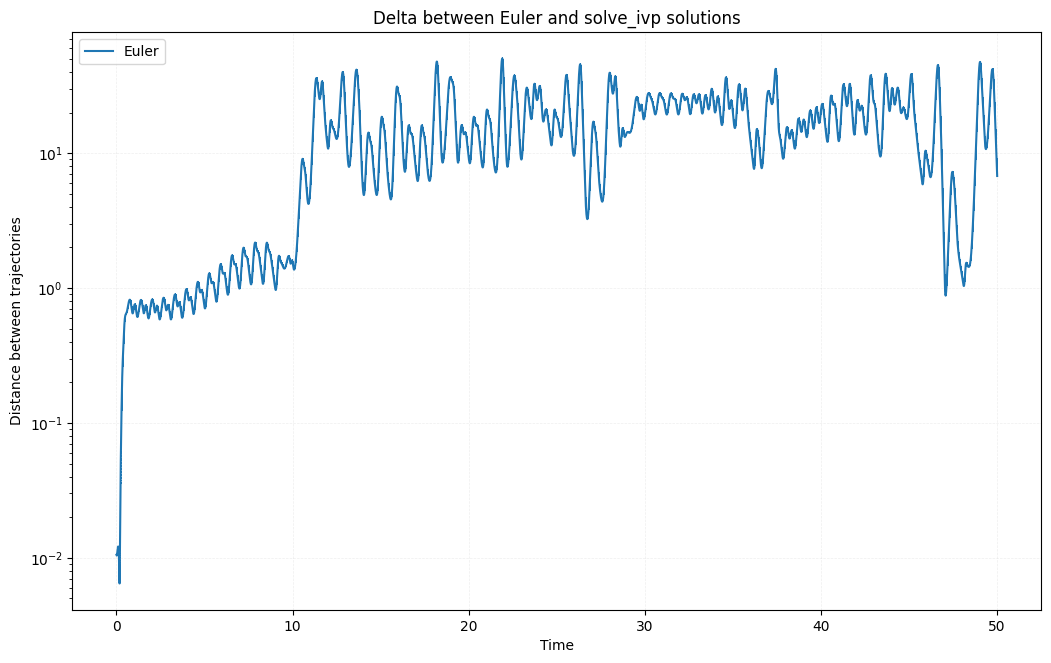

In [ ]:
delta_n_ie = (np.sum(delta_ie**2, axis = 1)**0.5)
xs = np.linspace(0,50,delta_n_ie.shape[0])
plt.figure(figsize = (12.5,7.5))
plt.loglog(xs, delta_n_ie, marker = ',', label='Euler')
plt.title('Delta between Euler and solve_ivp solutions')
plt.xlabel('Time')
plt.ylabel('Distance between trajectories')
plt.grid(True, which='major', ls='--', lw=0.5, alpha=0.2)
plt.legend()
plt.show()


We can see that the error grows exponentially, until the compounding error in our approximation and the chaotic behavior of the system completely take over, and we're left with nothing but noise. 

## Conclusions

- Implemented `LorenzSystem`  using the `lorenz_sim_euler`, `lorenz_sim_rk`, and `lorenz_solve_ivp` methods.
- Plotted the Lorenz attractor
- Demonstrated the sensitivity to intital conditions of chaotic dynamical systems.
- Compared the adaptive resolution RK45 approach to Euler's algorithm, and plotted the difference.

## References

- [Lorenz system (Wikipedia)](https://en.wikipedia.org/wiki/Lorenz_system)
- [Chaos theory (Scholarpedia)](http://www.scholarpedia.org/article/Chaos)
